In [1]:
# ============================================================
# STEP 1: Mount Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ============================================================
# STEP 2: Import libraries
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
# ============================================================
# STEP 3: Load dataset from Google Drive
# Replace the path with your actual CSV file path
# ============================================================
df = pd.read_csv("/content/drive/MyDrive/medical_insurance.csv")

# Shuffle dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Display first rows
df.head()

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,48299,60,Male,East,Urban,30600.0,Masters,Single,Employed,4,...,0,0,1,1,0,1,0,1,1,1
1,81048,40,Male,North,Rural,55900.0,Some College,Married,Employed,2,...,0,0,0,0,0,0,1,0,0,0
2,92755,55,Male,East,Urban,226200.0,HS,Married,Employed,3,...,0,0,0,0,0,1,0,0,1,0
3,46008,40,Female,Central,Suburban,70700.0,Some College,Married,Employed,3,...,0,1,0,1,0,0,1,0,0,0
4,76982,70,Male,West,Urban,107200.0,No HS,Single,Employed,2,...,0,1,0,0,0,0,1,1,1,0


In [4]:
# ============================================================
# STEP 4: Basic inspection
# ============================================================
print("Shape of dataset:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum().sort_values(ascending=False).head(20))

Shape of dataset: (100000, 54)

Columns:
 ['person_id', 'age', 'sex', 'region', 'urban_rural', 'income', 'education', 'marital_status', 'employment_status', 'household_size', 'dependents', 'bmi', 'smoker', 'alcohol_freq', 'visits_last_year', 'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs', 'medication_count', 'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c', 'plan_type', 'network_tier', 'deductible', 'copay', 'policy_term_years', 'policy_changes_last_2yrs', 'provider_quality', 'risk_score', 'annual_medical_cost', 'annual_premium', 'monthly_premium', 'claims_count', 'avg_claim_amount', 'total_claims_paid', 'chronic_count', 'hypertension', 'diabetes', 'asthma', 'copd', 'cardiovascular_disease', 'cancer_history', 'kidney_disease', 'liver_disease', 'arthritis', 'mental_health', 'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count', 'proc_consult_count', 'proc_lab_count', 'is_high_risk', 'had_major_procedure']

Data types:
 person_id                        int64
age      

In [5]:
# ============================================================
# STEP 5: Define target and remove unnecessary columns
# ============================================================
target_col = "annual_medical_cost"

# Drop ID column if present
drop_cols = []
if "person_id" in df.columns:
    drop_cols.append("person_id")

# Create X and y
X = df.drop(columns=drop_cols + [target_col])
y = df[target_col]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (100000, 52)
Target shape: (100000,)


In [6]:
# ============================================================
# STEP 6: Split data into Train (70%), Validation (10%), Test (20%)
# First: split off 20% test
# Second: split remaining 80% into 70/10
# 10/80 = 0.125
# ============================================================
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=42
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (70000, 52)
Validation shape: (10000, 52)
Test shape: (20000, 52)


In [7]:
# ============================================================
# STEP 7: Identify numeric and categorical columns
# ============================================================
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric features:", numeric_features)
print("\nCategorical features:", categorical_features)

Numeric features: ['age', 'income', 'household_size', 'dependents', 'bmi', 'visits_last_year', 'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs', 'medication_count', 'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c', 'deductible', 'copay', 'policy_term_years', 'policy_changes_last_2yrs', 'provider_quality', 'risk_score', 'annual_premium', 'monthly_premium', 'claims_count', 'avg_claim_amount', 'total_claims_paid', 'chronic_count', 'hypertension', 'diabetes', 'asthma', 'copd', 'cardiovascular_disease', 'cancer_history', 'kidney_disease', 'liver_disease', 'arthritis', 'mental_health', 'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count', 'proc_consult_count', 'proc_lab_count', 'is_high_risk', 'had_major_procedure']

Categorical features: ['sex', 'region', 'urban_rural', 'education', 'marital_status', 'employment_status', 'smoker', 'alcohol_freq', 'plan_type', 'network_tier']


In [8]:
# ============================================================
# STEP 8: Build preprocessing pipelines
# Numeric: median imputation + scaling
# Categorical: most frequent imputation + one-hot encoding
# ============================================================
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [9]:
# ============================================================
# STEP 9: Define hyperparameter grid for SVR
# Kernel choices:
# - rbf: best for non-linear relationships
# - linear: simpler baseline
# C controls regularization
# epsilon controls tolerance margin
# gamma controls influence range for rbf kernel
# ============================================================
param_grid = {
    "svr__kernel": ["rbf", "linear"],
    "svr__C": [1, 10, 50],
    "svr__epsilon": [0.1, 1.0, 5.0],
    "svr__gamma": ["scale"]  # used mainly for rbf
}

In [10]:
# ============================================================
# STEP 10: FAST SVR tuning using subset + reduced grid
# ============================================================

# 🔥 Use smaller subset for tuning (IMPORTANT)
sample_size = 20000  # you can reduce to 10000 if still slow

X_train_sample = X_train.sample(n=sample_size, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]

results = []

# 🔥 Reduced hyperparameter grid (faster)
param_grid_fast = {
    "svr__kernel": ["rbf"],        # only best kernel
    "svr__C": [10, 50],           # reduced values
    "svr__epsilon": [0.1, 1.0],   # reduced values
    "svr__gamma": ["scale"]
}

for params in ParameterGrid(param_grid_fast):
    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("svr", SVR())
    ])

    model.set_params(**params)

    # 🔥 Train on smaller subset
    model.fit(X_train_sample, y_train_sample)

    # Training predictions (on sample)
    y_train_pred = model.predict(X_train_sample)

    # Validation predictions (full validation set)
    y_val_pred = model.predict(X_val)

    # Metrics
    train_mae = mean_absolute_error(y_train_sample, y_train_pred)
    train_mse = mean_squared_error(y_train_sample, y_train_pred)
    train_rmse = np.sqrt(train_mse)
    train_r2 = r2_score(y_train_sample, y_train_pred)

    val_mae = mean_absolute_error(y_val, y_val_pred)
    val_mse = mean_squared_error(y_val, y_val_pred)
    val_rmse = np.sqrt(val_mse)
    val_r2 = r2_score(y_val, y_val_pred)

    results.append({
        "kernel": params["svr__kernel"],
        "C": params["svr__C"],
        "epsilon": params["svr__epsilon"],
        "gamma": params["svr__gamma"],
        "train_mae": train_mae,
        "train_mse": train_mse,
        "train_rmse": train_rmse,
        "train_r2": train_r2,
        "val_mae": val_mae,
        "val_mse": val_mse,
        "val_rmse": val_rmse,
        "val_r2": val_r2
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="val_rmse", ascending=True).reset_index(drop=True)

print("Top validation results:")
display(results_df)

Top validation results:


,kernel,C,epsilon,gamma,train_mae,train_mse,train_rmse,train_r2,val_mae,val_mse,val_rmse,val_r2
0,rbf,50,1.0,scale,645.214464,4.148973e+06,2036.902782,0.581154,660.332592,4.491729e+06,2119.369844,0.555262
1,rbf,50,0.1,scale,645.182899,4.149096e+06,2036.933041,0.581142,660.333616,4.491853e+06,2119.399311,0.555250
2,rbf,10,0.1,scale,1094.534414,6.130367e+06,2475.957874,0.381129,1089.618801,6.377068e+06,2525.285733,0.368590
3,rbf,10,1.0,scale,1094.497874,6.130553e+06,2475.995260,0.381111,1089.571693,6.377233e+06,2525.318344,0.368574


In [11]:
# ============================================================
# STEP 11: Select best hyperparameters
# ============================================================
best_row = results_df.iloc[0]
print("Best hyperparameters based on validation RMSE:\n")
print(best_row)

Best hyperparameters based on validation RMSE:

kernel                   rbf
C                         50
epsilon                  1.0
gamma                  scale
train_mae         645.214464
train_mse     4148972.944784
train_rmse       2036.902782
train_r2            0.581154
val_mae           660.332592
val_mse        4491728.53552
val_rmse         2119.369844
val_r2              0.555262
Name: 0, dtype: object


In [12]:
# ============================================================
# STEP 12: Retrain best model using Train + Validation sets
# ============================================================
X_train_final = pd.concat([X_train, X_val], axis=0)
y_train_final = pd.concat([y_train, y_val], axis=0)

best_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("svr", SVR(
        kernel=best_row["kernel"],
        C=best_row["C"],
        epsilon=best_row["epsilon"],
        gamma=best_row["gamma"]
    ))
])

best_model.fit(X_train_final, y_train_final)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'income',
                                                   'household_size',
                                                   'dependents', 'bmi',
                                                   'visits_last_year',
                                                   'hospitalizations_last_3yrs',
                                                   'days_hospitalized_last_3yrs',
                                                   'medication_count',
                                                   'systolic_bp',
                                                   'diastolic_bp', 'ldl',
                                                   'hba...
                                                   'asthma', 'copd',
                                                   'cardiovascular_disease', ...]),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'region',
                                                   'urban_rural', 'education',
                                                   'marital_status',
                                                   'employment_status',
                                                   'smoker', 'alcohol_freq',
                                                   'plan_type',
                                                   'network_tier'])])),
                ('svr', SVR(C=np.int64(50), epsilon=np.float64(1.0)))])

In [13]:
# ============================================================
# STEP 13: Final testing on the test set
# ============================================================
y_test_pred = best_model.predict(X_test)

test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

print("Final Test Results")
print("-------------------")
print(f"MAE  : {test_mae:.4f}")
print(f"MSE  : {test_mse:.4f}")
print(f"RMSE : {test_rmse:.4f}")
print(f"R^2  : {test_r2:.4f}")

Final Test Results
-------------------
MAE  : 454.3169
MSE  : 3076867.7119
RMSE : 1754.1003
R^2  : 0.6852


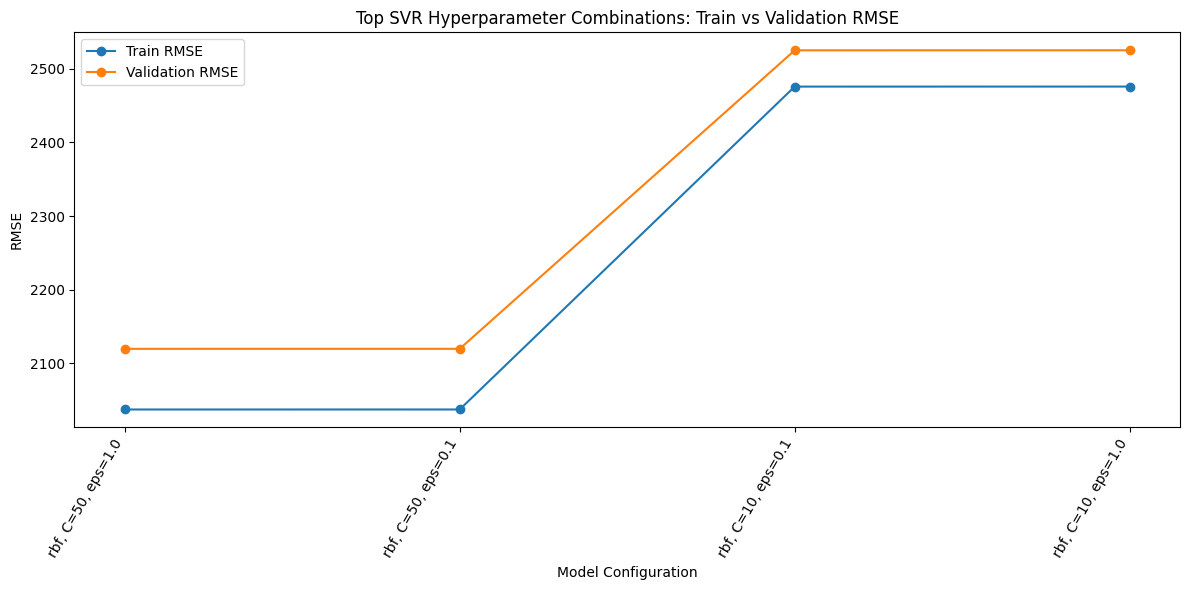

In [14]:
# ============================================================
# STEP 14: Training vs Validation RMSE visualization
# ============================================================
top_n = 10
plot_df = results_df.head(top_n).copy()
plot_df["label"] = (
    plot_df["kernel"] + ", C=" + plot_df["C"].astype(str) +
    ", eps=" + plot_df["epsilon"].astype(str)
)

plt.figure(figsize=(12, 6))
plt.plot(plot_df["label"], plot_df["train_rmse"], marker="o", label="Train RMSE")
plt.plot(plot_df["label"], plot_df["val_rmse"], marker="o", label="Validation RMSE")
plt.xticks(rotation=60, ha="right")
plt.title("Top SVR Hyperparameter Combinations: Train vs Validation RMSE")
plt.xlabel("Model Configuration")
plt.ylabel("RMSE")
plt.legend()
plt.tight_layout()
plt.show()

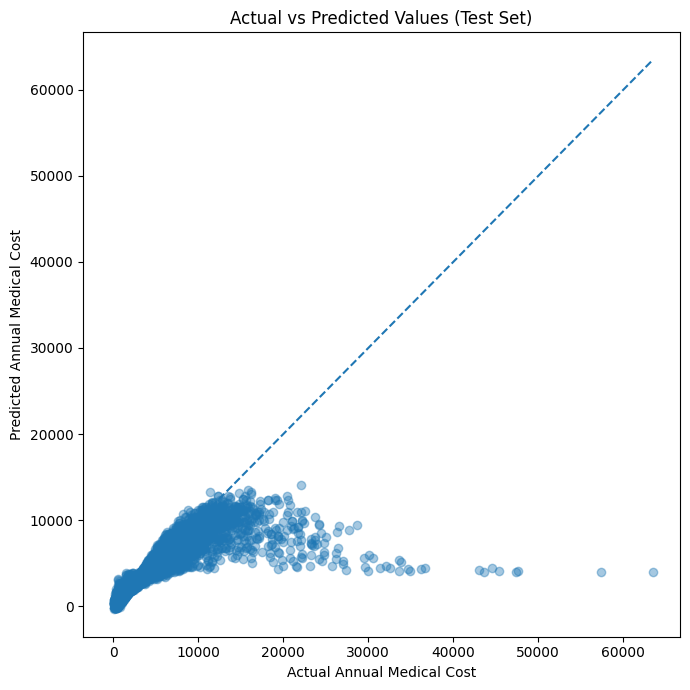

In [15]:
# ============================================================
# STEP 15: Actual vs Predicted on Test Set
# ============================================================
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_test_pred, alpha=0.4)
plt.xlabel("Actual Annual Medical Cost")
plt.ylabel("Predicted Annual Medical Cost")
plt.title("Actual vs Predicted Values (Test Set)")

min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.tight_layout()
plt.show()

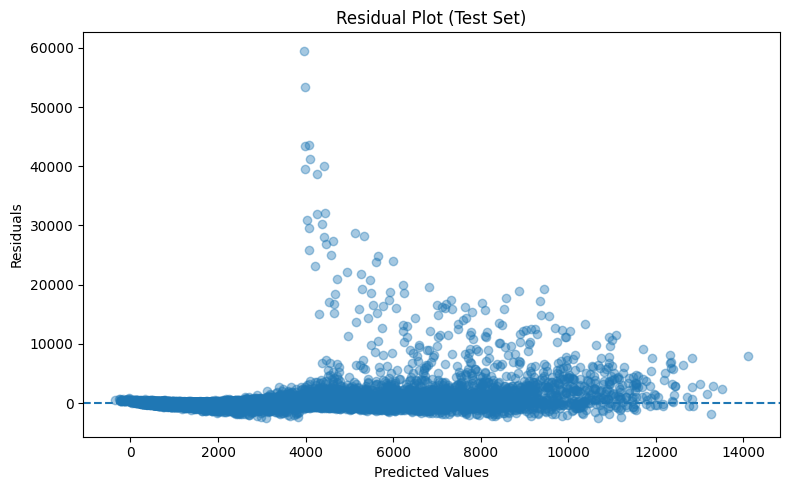

In [16]:
# ============================================================
# STEP 16: Residual plot
# ============================================================
residuals = y_test - y_test_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_test_pred, residuals, alpha=0.4)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot (Test Set)")
plt.tight_layout()
plt.show()

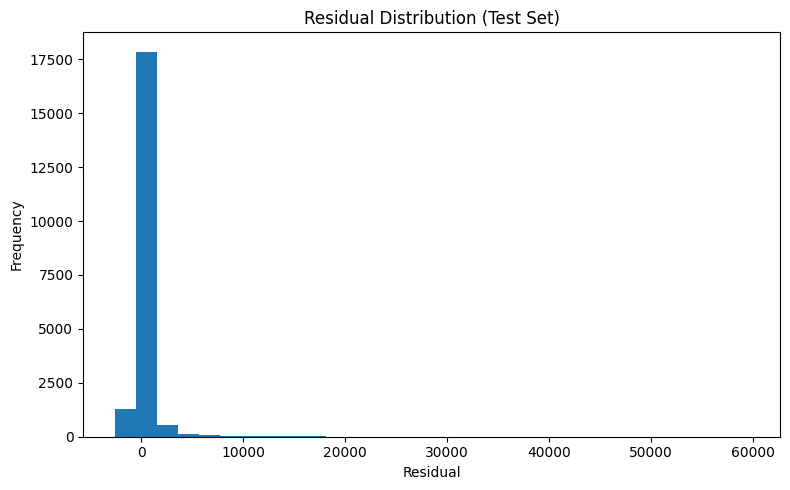

In [17]:
# ============================================================
# STEP 17: Distribution of residuals
# ============================================================
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution (Test Set)")
plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# STEP 18: Save results to CSV for your report
# ============================================================
results_df.to_csv("/content/drive/MyDrive/svr_v2/svr_validation_results.csv", index=False)

test_results_df = pd.DataFrame([{
    "test_mae": test_mae,
    "test_mse": test_mse,
    "test_rmse": test_rmse,
    "test_r2": test_r2,
    "best_kernel": best_row["kernel"],
    "best_C": best_row["C"],
    "best_epsilon": best_row["epsilon"],
    "best_gamma": best_row["gamma"]
}])

test_results_df.to_csv("/content/drive/MyDrive/svr_v2/svr_test_results.csv", index=False)

print("Saved validation and test results to Google Drive.")

Saved validation and test results to Google Drive.
